# ncfrec: Neural Collaborative Filtering

Train a **NeuMF** recommender on MovieLens 100K, evaluate Top-N ranking quality, export a versioned artifact, and verify it through the same Python inference service used by an application.

Dataset: [GroupLens MovieLens 100K](https://grouplens.org/datasets/movielens/100k/). Review the dataset README and usage terms before redistribution. Source information is rephrased for licensing compliance.

## 1. Environment and imports
The notebook imports reusable code from `src/ncfrec`; training and production inference therefore share one model implementation.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src" / "ncfrec").exists():
    raise RuntimeError("Run this notebook from the ncfrec repository root or notebooks directory")
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

from ncfrec.artifacts import save_artifact
from ncfrec.config import DataConfig, ModelConfig, TrainingConfig
from ncfrec.data import (
    InteractionDataset,
    download_movielens,
    load_movielens,
    prepare_data,
    sample_training_instances,
)
from ncfrec.model import NeuMF
from ncfrec.recommender import NCFRecommender
from ncfrec.training import evaluate_ranking, set_seed, train_one_epoch

print(f"Torch: {torch.__version__}")
print(f"Project root: {ROOT}")

Torch: 2.14.0+cu130
Project root: /home/harshil/ncfrec


## 2. Reproducible configuration
Set `NCFREC_EPOCHS=1` for a quick pipeline check or leave it unset for the default five-epoch experiment.

In [2]:
data_config = DataConfig(positive_rating=4.0, negatives_per_positive=4, seed=42)
training_config = TrainingConfig(
    epochs=int(os.getenv("NCFREC_EPOCHS", "5")),
    batch_size=1024,
    learning_rate=1e-3,
    weight_decay=1e-5,
    evaluation_k=10,
)
set_seed(data_config.seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(data_config)
print(training_config)
print(f"Device: {device}")

DataConfig(positive_rating=4.0, negatives_per_positive=4, seed=42)
TrainingConfig(epochs=5, batch_size=1024, learning_rate=0.001, weight_decay=1e-05, evaluation_k=10)
Device: cuda


## 3. Download and inspect MovieLens 100K
The downloader is idempotent: after the first run, it reuses local files under `data/`.

In [3]:
raw_dir = download_movielens(ROOT / "data")
ratings, movies = load_movielens(raw_dir)
print(f"{len(ratings):,} ratings | {ratings.user_id.nunique():,} users | {ratings.movie_id.nunique():,} rated movies")
ratings.head()

100,000 ratings | 943 users | 1,682 rated movies


,user_id,movie_id,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


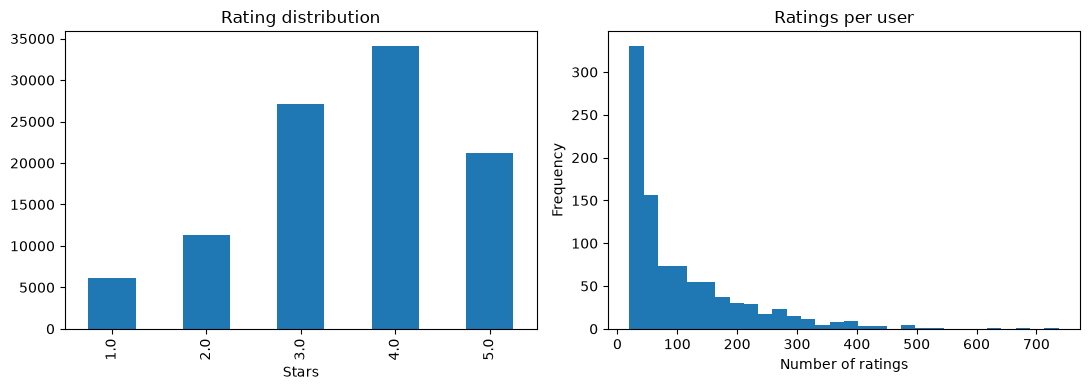

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ratings["rating"].value_counts().sort_index().plot.bar(ax=axes[0], title="Rating distribution")
ratings.groupby("user_id").size().plot.hist(bins=30, ax=axes[1], title="Ratings per user")
axes[0].set_xlabel("Stars")
axes[1].set_xlabel("Number of ratings")
plt.tight_layout()
plt.show()

## 4. Convert ratings to implicit feedback
Ratings of four or five stars are positive interactions. For users with enough positives, the latest positive is test data and the previous positive is validation data. This chronological split better represents future recommendation behavior than a random split.

In [5]:
prepared = prepare_data(ratings, movies, positive_rating=data_config.positive_rating)
split_summary = pd.Series({
    "train positives": len(prepared.train),
    "validation positives": len(prepared.validation),
    "test positives": len(prepared.test),
    "users": prepared.num_users,
    "items": prepared.num_items,
})
split_summary

train positives         53491
validation positives      942
test positives            942
users                     943
items                    1682
dtype: int64

In [6]:
training_frame = sample_training_instances(
    prepared.train,
    num_items=prepared.num_items,
    excluded_items=prepared.seen_items,
    negatives_per_positive=data_config.negatives_per_positive,
    seed=data_config.seed,
)
training_loader = DataLoader(
    InteractionDataset(training_frame),
    batch_size=training_config.batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(data_config.seed),
)
print(training_frame["label"].value_counts().sort_index())
print(f"Training rows after negative sampling: {len(training_frame):,}")

label
0.0    213964
1.0     53491
Name: count, dtype: int64
Training rows after negative sampling: 267,455


## 5. Build and train NeuMF
NeuMF combines a generalized matrix-factorization path with a multilayer perceptron. The model predicts an interaction logit and is optimized with binary cross-entropy.

In [7]:
model_config = ModelConfig(
    num_users=prepared.num_users,
    num_items=prepared.num_items,
    embedding_dim=32,
    mlp_layers=(128, 64, 32),
    dropout=0.2,
)
model = NeuMF(model_config).to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=training_config.learning_rate,
    weight_decay=training_config.weight_decay,
)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Trainable parameters: {parameter_count:,}")

NeuMF(
  (gmf_user_embedding): Embedding(943, 32)
  (gmf_item_embedding): Embedding(1682, 32)
  (mlp_user_embedding): Embedding(943, 32)
  (mlp_item_embedding): Embedding(1682, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
  )
  (output): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 186,721


In [8]:
def items_by_user(*frames):
    combined = pd.concat(frames, ignore_index=True)
    return {
        int(user): set(int(item) for item in group["item_idx"])
        for user, group in combined.groupby("user_idx")
    }

validation_blocked = items_by_user(prepared.train)
history = []
for epoch in range(1, training_config.epochs + 1):
    loss = train_one_epoch(model, training_loader, optimizer, device)
    validation_metrics = evaluate_ranking(
        model, prepared.validation, validation_blocked, training_config.evaluation_k, device
    )
    row = {"epoch": epoch, "loss": loss, **validation_metrics}
    history.append(row)
    print(row)

history_frame = pd.DataFrame(history)
history_frame

{'epoch': 1, 'loss': 0.37254802450921837, 'hit_rate@10': 0.05201698513800425, 'ndcg@10': 0.026181413459409785}
{'epoch': 2, 'loss': 0.3143977500200918, 'hit_rate@10': 0.06263269639065817, 'ndcg@10': 0.029904804939550198}
{'epoch': 3, 'loss': 0.2928505109108445, 'hit_rate@10': 0.07218683651804671, 'ndcg@10': 0.033100778087328656}
{'epoch': 4, 'loss': 0.26802502969653763, 'hit_rate@10': 0.08174097664543524, 'ndcg@10': 0.0369136681781326}
{'epoch': 5, 'loss': 0.2528162859250848, 'hit_rate@10': 0.08492569002123142, 'ndcg@10': 0.03869813721183489}


,epoch,loss,hit_rate@10,ndcg@10
0,1,0.372548,0.052017,0.026181
1,2,0.314398,0.062633,0.029905
2,3,0.292851,0.072187,0.033101
3,4,0.268025,0.081741,0.036914
4,5,0.252816,0.084926,0.038698


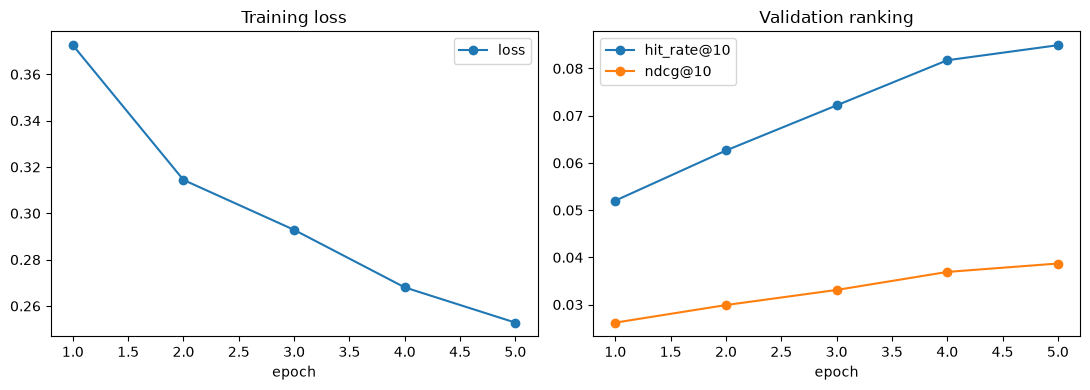

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
history_frame.plot(x="epoch", y="loss", marker="o", ax=axes[0], title="Training loss")
metric_columns = [column for column in history_frame if "@" in column]
history_frame.plot(x="epoch", y=metric_columns, marker="o", ax=axes[1], title="Validation ranking")
plt.tight_layout()
plt.show()

## 6. Final test evaluation
The test set is evaluated once after training. Already-known training and validation positives are removed from each user's candidate catalog.

In [10]:
test_blocked = items_by_user(prepared.train, prepared.validation)
test_metrics = evaluate_ranking(
    model, prepared.test, test_blocked, training_config.evaluation_k, device
)
test_metrics

{'hit_rate@10': 0.06900212314225053, 'ndcg@10': 0.031133240057535577}

## 7. Export and production-style inference
Weights and validated JSON metadata are stored separately. The inference facade loads them once, rejects unknown IDs, excludes previously rated movies, and returns serializable recommendations.

In [11]:
artifact_dir = save_artifact(
    model=model,
    artifact_dir=ROOT / "artifacts" / "movielens-100k-neumf",
    raw_user_to_index=prepared.raw_user_to_index,
    raw_movie_to_index=prepared.raw_movie_to_index,
    movie_titles_by_index=prepared.movie_titles_by_index,
    seen_items=prepared.seen_items,
)
print(f"Saved artifact to: {artifact_dir}")

Saved artifact to: /home/harshil/ncfrec/artifacts/movielens-100k-neumf


In [12]:
service = NCFRecommender.from_artifact(artifact_dir, device="cpu")
sample_user_id = next(iter(prepared.raw_user_to_index))
print(service.health())
pd.DataFrame([recommendation.to_dict() for recommendation in service.recommend(sample_user_id, k=10)])

{'status': 'ready', 'num_users': 943, 'num_items': 1682, 'device': 'cpu'}


,movie_id,title,score
0,483,Casablanca (1942),0.894393
1,423,E.T. the Extra-Terrestrial (1982),0.893193
2,357,One Flew Over the Cuckoo's Nest (1975),0.883241
3,318,Schindler's List (1993),0.877885
4,496,It's a Wonderful Life (1946),0.793953
5,603,Rear Window (1954),0.782677
6,427,To Kill a Mockingbird (1962),0.781335
7,655,Stand by Me (1986),0.780421
8,435,Butch Cassidy and the Sundance Kid (1969),0.755233
9,527,Gandhi (1982),0.752919


## Next production steps
For an online system, place `NCFRecommender` behind an API, record model/data versions in deployment metadata, monitor recommendation coverage and drift, and define a cold-start strategy for unknown users and new movies.